In [ ]:
# Brain Tumour Classification using Machine Learning

In [ ]:
import matplotlib.pyplot as plt
import argparse
import os
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from glob import glob

path = "/content/drive/MyDrive/brain_tumor_dataset"

yes_images = os.path.join(path, "yes")
no_images = os.path.join(path, "no")

In [ ]:
image_paths = []

valid_exts = {'jpg', 'png', 'jpeg', 'JPG'}

for image_path in os.listdir(yes_images):
  *_, ext = image_path.split(".")
  if ext in valid_exts:
    image_paths.append(os.path.join(path, "yes", image_path))

exts = []
for image_path in os.listdir(no_images):
  _, ext = image_path.split(".")
  if ext in valid_exts:
    image_paths.append(os.path.join(path, "no", image_path))

In [ ]:
images = []
labels = []

for image_path in image_paths:
  *_, label, _ = image_path.split(os.path.sep)

  image = cv2.imread(image_path)
  image = cv2.resize(image, (224, 224))

  images.append(image)
  labels.append(label)

In [ ]:
len(image_paths)

253

Number of images loaded: 253
Number of labels loaded: 253


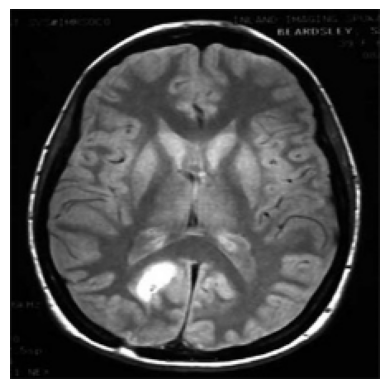

In [ ]:
print("Number of images loaded:", len(images))
print("Number of labels loaded:", len(labels))

if len(images) > 0:
    plt.imshow(images[0])
    plt.axis("off")
    plt.show()
else:
    print("No images were loaded. Check your dataset path.")


In [ ]:
print("Total image paths found:", len(image_paths))
print("First few paths:", image_paths[:5])

Total image paths found: 253
First few paths: ['/content/drive/MyDrive/brain_tumor_dataset/yes/Y156.JPG', '/content/drive/MyDrive/brain_tumor_dataset/yes/Y24.jpg', '/content/drive/MyDrive/brain_tumor_dataset/yes/Y112.JPG', '/content/drive/MyDrive/brain_tumor_dataset/yes/Y115.JPG', '/content/drive/MyDrive/brain_tumor_dataset/yes/Y103.jpg']


In [ ]:
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.utils import to_categorical
import numpy as np

images = np.array(images) / 255.0
labels = np.array(labels)

label_binarizer = LabelBinarizer()
labels = label_binarizer.fit_transform(labels)
labels = to_categorical(labels)

In [ ]:
from sklearn.model_selection import train_test_split

(train_X, test_X, train_Y, test_Y) = train_test_split(images, labels, test_size= 0.10, random_state= 42, stratify= labels)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_generator = ImageDataGenerator(fill_mode= 'nearest', rotation_range= 15)

In [ ]:
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights= 'imagenet', input_tensor= Input(shape = (224, 224, 3)), include_top= False)
base_input = base_model.input

base_output = base_model.output
base_output = AveragePooling2D(pool_size=(4, 4))(base_output)
base_output = Flatten(name="flatten")(base_output)
base_output = Dense(64, activation="relu")(base_output)
base_output = Dropout(0.5)(base_output)
base_output = Dense(2, activation="softmax")(base_output)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

model = Model(inputs = base_input, outputs = base_output)
model.compile(optimizer= Adam(learning_rate= 1e-3), metrics= ['accuracy'], loss= 'binary_crossentropy')

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 1, 512)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 14,747,650 (56.26 MB)

 Trainable params: 32,962 (128.76 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
batch_size = 8
train_steps = len(train_X) // batch_size
validation_steps = len(test_X) // batch_size
epochs = 10

In [ ]:
history = model.fit(train_generator.flow(train_X, train_Y, batch_size= batch_size), steps_per_epoch= train_steps, validation_data = (test_X, test_Y), epochs= epochs)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 149s 5s/step - accuracy: 0.5777 - loss: 0.7387 - val_accuracy: 0.6154 - val_loss: 0.6194
Epoch 2/10
 1/28 ━━━━━━━━━━━━━━━━━━━━ 1:58 4s/step - accuracy: 0.3750 - loss: 0.8234

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


28/28 ━━━━━━━━━━━━━━━━━━━━ 25s 759ms/step - accuracy: 0.3750 - loss: 0.8234 - val_accuracy: 0.6154 - val_loss: 0.6182
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 139s 5s/step - accuracy: 0.6482 - loss: 0.6286 - val_accuracy: 0.8077 - val_loss: 0.5997
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 519ms/step - accuracy: 0.6250 - loss: 0.6793 - val_accuracy: 0.8462 - val_loss: 0.6005
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 134s 5s/step - accuracy: 0.6521 - loss: 0.6473 - val_accuracy: 0.8077 - val_loss: 0.5638
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 24s 759ms/step - accuracy: 0.7500 - loss: 0.5330 - val_accuracy: 0.8462 - val_loss: 0.5656
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 138s 5s/step - accuracy: 0.6620 - loss: 0.6138 - val_accuracy: 0.8462 - val_loss: 0.5362
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 24s 759ms/step - accuracy: 0.8750 - loss: 0.4987 - val_accuracy: 0.8462 - val_loss: 0.5357
Epoch 9/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 183s 5s/step - accuracy: 0.7521 - loss: 0.5344 - val_accuracy: 0.6538 - val_

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = model.predict(test_X, batch_size= batch_size)
predictions = np.argmax(predictions, axis= 1)
actuals = np.argmax(test_Y, axis= 1)

print(classification_report(actuals, predictions, target_names= label_binarizer.classes_))

cm = confusion_matrix(actuals, predictions)
print(cm)

4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step
              precision    recall  f1-score   support

          no       0.53      0.90      0.67        10
         yes       0.89      0.50      0.64        16

    accuracy                           0.65        26
   macro avg       0.71      0.70      0.65        26
weighted avg       0.75      0.65      0.65        26

[[9 1]
 [8 8]]


In [ ]:
total = sum(sum(cm))
accuracy = (cm[0, 0] + cm[1, 1]) / total
print("Accuracy: {:.4f}".format(accuracy))

Accuracy: 0.6538


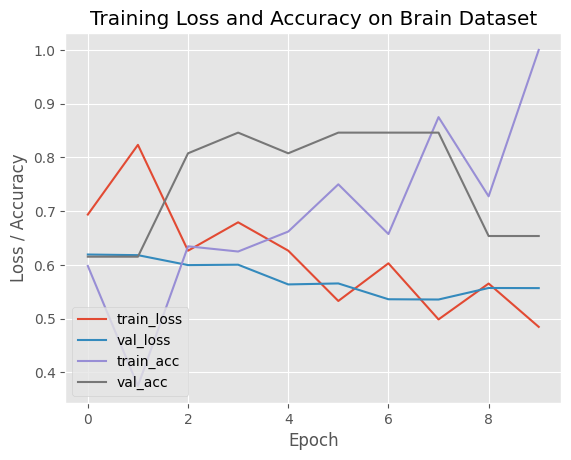

In [ ]:
N = epochs
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), history.history["loss"], label= "train_loss")
plt.plot(np.arange(0, N), history.history["val_loss"], label= "val_loss")

plt.plot(np.arange(0, N), history.history["accuracy"], label= "train_acc")
plt.plot(np.arange(0, N), history.history["val_accuracy"], label= "val_acc")

plt.title("Training Loss and Accuracy on Brain Dataset")
plt.xlabel("Epoch")
plt.ylabel("Loss / Accuracy")
plt.legend(loc= "lower left")
plt.savefig("plot.jpg")